### Summary 

This analysis uses supervised learning methods to predict the probability of default among Taiwanese credit card users.

### Data 

The Taiwan credit default dataset has 30,000 clients and 23 predictors. The response variable is default.payment.next.month (1 on default, 0 otherwise). 

Predictors include: 

- demographics (SEX, EDUCATION, MARRIAGE, AGE) 
- credit limit (LIMIT_BAL) 
- six months of past repayment status (PAY_0 to PAY_5) 
- six months of bill statements (BILL_AMT1 to BILL_AMT6) 
- six months of past payments (PAY_AMT1 to PAY_AMT6) 

Note that features like age (years) and bill amounts (in NT dollars) are on very different scales. Approximately 22% of clients defaulted. 

### Models
#### Preprocessing 

First, the ID column and header row were manually removed from the dataset. Then, it was split 2:1 training to testing.

#### Model 1: Logistic Regression (GLM)
Generalised Linear Models (GLMs) extend ordinary linear regression to accommodate non-normal data using maximum likelihood estimation. One such case suited to a GLM is when the responses follow a Bernoulli distribution (i.e. binary outcome). 

$$ y \sim Ber(\pi) $$

In this case, the GLM is called a logistic regression which relates the predictors to the response variables via the logit link function

$$ logit(\pi) = log (\frac{\pi}{1-\pi}) $$

where $\pi(x)=P(Y|X)$. <br>

Algorithms based on modeling such conditional probablities are known as discriminative learning algorithms. 

#### Model 2: Support Vector Machines (SVMs)

Support Vector Classifiers attempt to find a linear boundary that separates two classes while maximising the margin between them. The classification is based on the linear function

$$ f(x) = \beta_0 + \beta^Tx $$

SVMs extend this idea by enlarging the feature space using kernel functions. It projects the data into a higher-dimensional feature space and computes a separating hyperplane that can capture nonlinear relationships between the predictors and the outcome.

In this analysis a linear kernel was used, meaning the decision boundary remains linear, followed by a (Gaussian) Radial Basis Function (RBF) which allows for a non-linear decision boundary.

### Results 

#### Logistic Regression
Logistic regression achieved about 81% accuracy on the test data. The model demonstrated higher accuracy when identifying non-defaults (97.5%) compared to defaults (23.0%). Considering the data is dominated by non-defaults, this outcome is unsurprising as it means the model had considerably less default data with which to learn. The model required 0.35s to run.

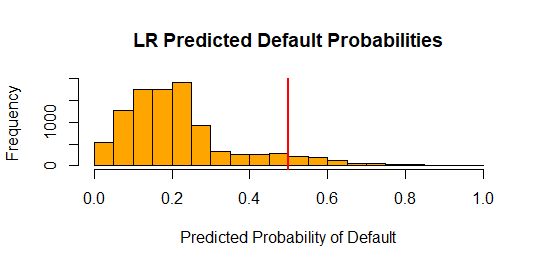


| Predicted | Actual 0 | Actual 1 |
|----|----|----|
| 0 | 7595 | 1702 |
| 1 | 195 | 508 |


#### SVM
##### Tuning
A range of cost hyperparameters were tested, from which the value 0.1 was chosen. The tuning was set to 2-fold cross-validation (instead of the default 10-fold) for the sake of speed and to avoid a memory error. Scaling was set to True, as the predictors within the set have very different scales and this can negatively affect the models, especially RBF. 

| cost | error | dispersion |
|----|----|----|
| 0.01 | 0.1916 | 0.0050911688 |
| 0.10 | 0.1915 | 0.0055154329 |
| 1 | 0.1918 | 0.0039597980 |
| 10 | 0.1939 | 0.0001414214 |

##### Linear Kernel
SVM with a linear kernel gave a similar overall accuracy of 80%. Again, the model demonstrated higher accuracy when identifying non-defaults (97.3%) than defaults (22.4%) reflecting the imbalance of non-default vs default data within the dataset. Considering the model is set to a linear kernel, the decision boundary is a linear hyperplane. Logistic regression also produces a linear boundary, so it is unsurprising that the results are very similar. It took 68s to run.

| Predicted | Actual 0 | Actual 1 |
|----|----|----|
| 0 | 7581 | 1714 |
| 1 | 209 | 496 |

##### RBF Kernel
Lastly SVM was run with an RBF kernel to test if there's a detectable non-linear relationship between the predictors and regressors. Overall accuracy was again around 82%. The gamma hyperparameter was selected using a common rule of thumb: one divided by the number of predictors. This dataset has 23 predictors which means $\gamma$ ~ 0.043.

Results strongly suggest a non-linear structure within the data as non-defaults were predicted with 95.9% accuracy while defaults were predicted with 32.0% accuracy. This means RBF remained highly accurate when detecting non-defaults but substantially improved the detection of defaults compared to both logistic regression and a linear kernel. This model took 120s to run.

| Predicted | Actual 0 | Actual 1 |
|----|----|----|
| 0 | 7467 | 1503 |
| 1 | 323 | 707 |

### Conclusion

In conclusion, the linear models performed similarly, but there was a notable increase in the accuracy of the RBF model which indicates some non-linear structure within the data.

Logistic regression has the advantage of simplicity, speed and it provides explicit probability estimates, which is useful for interpretability. However the extra configurability and flexibility of SVM can outperform linear models with data that exhibits non-linear structure, as was the case here. 

These results suggest that while default behaviour is largely predictable with linear modelling, some nonlinear patterns may also exist.

In [ ]:
## Appendix ##

library(e1071)

# https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients
data = read.csv("default of credit card clients.csv")
data$default.payment.next.month = as.factor(data$default.payment.next.month)

set.seed(1)          # reproducible
n = nrow(data)       # count how many rows of data
pivot = sample(1:n, size = (2/3)*n) # find the index separating 2:1
train = data[pivot,] # 20000 training data points
test = data[-pivot,] # 10000 to make predictions on
n_test = nrow(test)

# 1) Logistic Regression
system.time({
  lr_train = glm(default.payment.next.month ~ .,
                 data = train,
                 family = "binomial")
  lr_pred = predict(lr_train, newdata = test, type = "response") # predict >50% = 1, 0 otherwise
})
res = table(Predicted = ifelse(lr_pred > 0.5, 1, 0), Actual = test$default.payment.next.month)
FF = res[1,1]
FT = res[1,2]
TF = res[2,1]
TT = res[2,2]

print('Non-default prediction accuracy:')
FF / (FF + TF)
print('Default prediction accuracy:')
TT / (TT + FT)
print('Overall accuracy:')
(TT + FF) / n_test

# histogram of predicted probabilities
hist(lr_pred,
     breaks = 30,
     main = "LR Predicted Default Probabilities",
     xlab = "Predicted Probability of Default",
     col='orange'
     )
abline(v = 0.5, col = "red", lwd = 2) # default vs non-default threshold


# 2) SVM
# hyperparameter tuning (linear)
train_cut = train[1:(5000*2),] # chop to save time since we're running 8 times (4 costs x 2 folds)
pick_c = tune(svm,
              default.payment.next.month ~ .,
              data = train_cut,
              kernel = "linear",
              scale = T,
              ranges = list(cost = c(0.01, 0.1, 1, 10)),
              tunecontrol = tune.control(cross = 2)
)
pick_c$performances # see how each cost param performed

# linear kernel
system.time({
  svm_train = svm(default.payment.next.month ~ .,
                  data = train,
                  kernel = "linear",
                  cost = 0.1,
                  scale = T)
  svm_pred = predict(svm_train, test)
})
res=table(Predicted = svm_pred, Actual = test$default.payment.next.month)
FF = res[1,1]
FT = res[1,2]
TF = res[2,1]
TT = res[2,2]

print('Non-default prediction accuracy:')
FF / (FF + TF)
print('Default prediction accuracy:')
TT / (TT + FT)
print('Overall accuracy:')
(TT + FF) / n_test

# rbf kernel
system.time({
  svm_train = svm(default.payment.next.month ~ .,
                  data = train,
                  kernel = "radial",
                  cost = 0.1,
                  scale = T,
                  gamma=(1/23)) # gamma rule of thumb: 1/no. of predictors
  svm_pred = predict(svm_train, test)
})
res=table(Predicted = svm_pred, Actual = test$default.payment.next.month)
FF = res[1,1]
FT = res[1,2]
TF = res[2,1]
TT = res[2,2]

print('Non-default prediction accuracy:')
FF / (FF + TF)
print('Default prediction accuracy:')
TT / (TT + FT)
print('Overall accuracy:')
(TT + FF) / n_test

### References
- Matuozzo, A. (2025). Statistical Learning. Lecture notes, Birkbeck, University of London.
- James, G., Witten, D., Hastie, T., & Tibshirani, R. (2013). An Introduction to Statistical Learning: With Applications in R. Springer, New York.
- Cortes, C., & Vapnik, V. (1995). Support-vector networks. Machine Learning, 20(3), 273–297.